# Explore here

In [85]:
from utils import db_connect
engine = db_connect()
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy import stats


In [86]:
df = pd.read_csv('/workspaces/Proyecto-de-Preprocesamiento-de-Datos/data/raw/AB_NYC_2019.csv') 

print(df.head())    


     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

In [87]:
total_data = df

print(total_data.info())
print(total_data.shape)
print (total_data.describe())

print(total_data.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [88]:
print(f"The number of duplicated Name records is: {total_data['name'].duplicated().sum()}")
print(f"The number of duplicated Host ID records is: {total_data['host_id'].duplicated().sum()}")
print(f"The number of duplicated ID records is: {total_data['id'].duplicated().sum()}")


The number of duplicated Name records is: 989
The number of duplicated Host ID records is: 11438
The number of duplicated ID records is: 0


total_data = total_data.drop(['id', 'name', 'host_name', 'last_review', 'reviews_per_month'], axis=1)
total_data.info()
print(total_data.head())

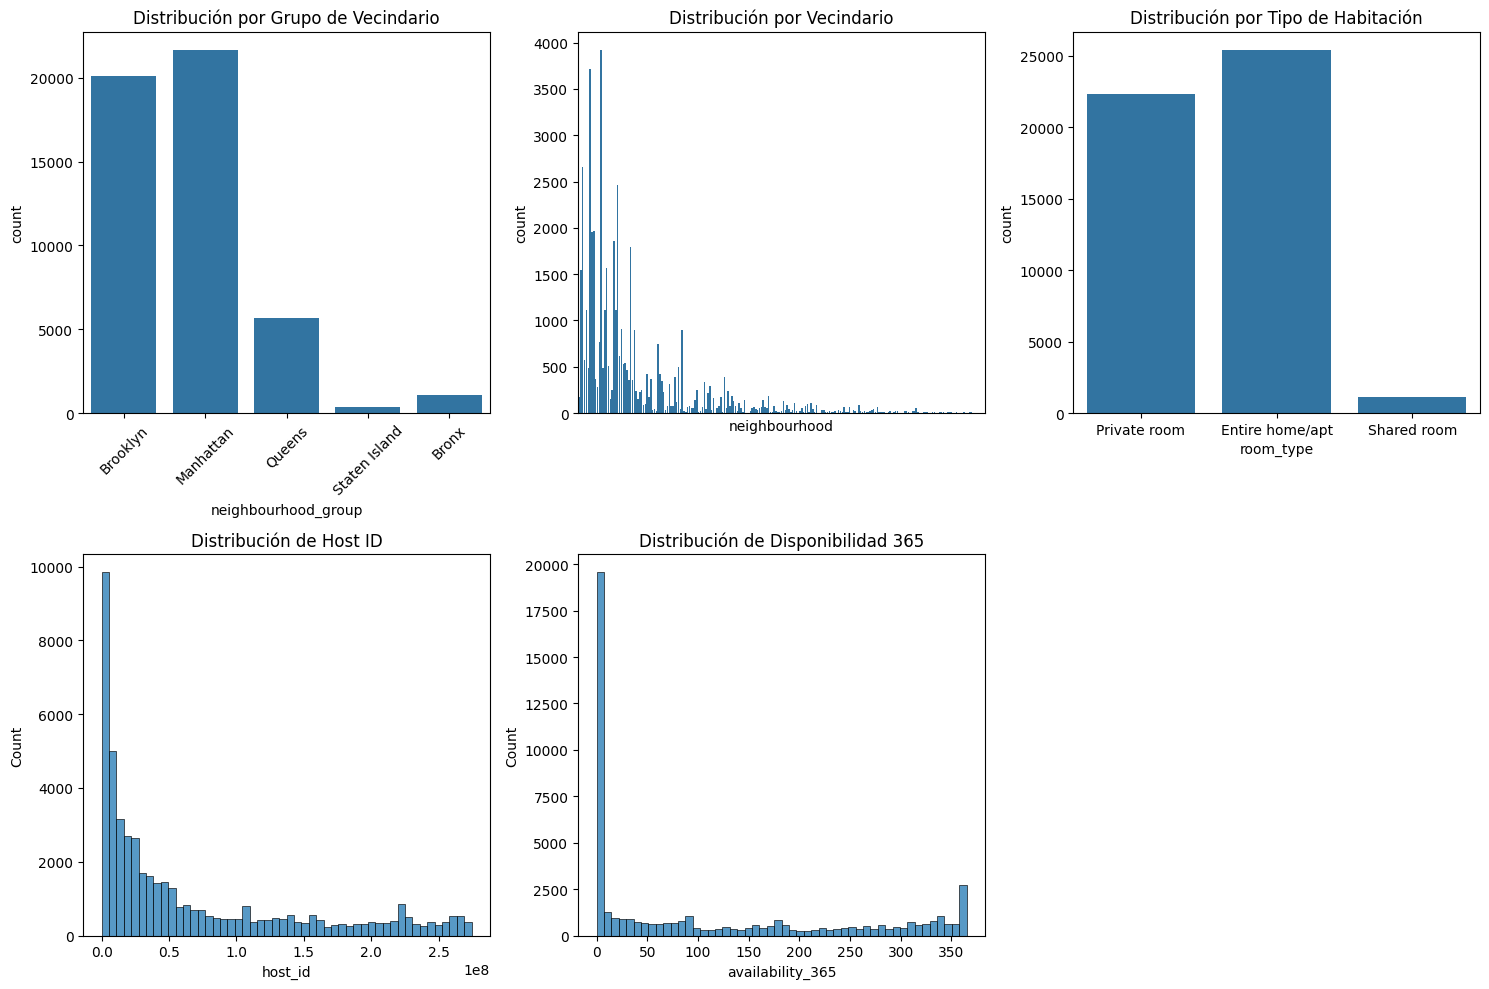

In [89]:
# Análisis de variables univariantes
fig, axis = plt.subplots(2, 3, figsize=(15, 10))  # Aumenté el tamaño para evitar superposiciones

# Variables categóricas: usar countplot en lugar de histplot
sns.countplot(ax=axis[0,0], data=total_data, x="neighbourhood_group")
axis[0,0].set_title("Distribución por Grupo de Vecindario")
axis[0,0].tick_params(axis='x', rotation=45)  # Rotar etiquetas si es necesario

sns.countplot(ax=axis[0,1], data=total_data, x="neighbourhood")
axis[0,1].set_title("Distribución por Vecindario")
axis[0,1].tick_params(axis='x', rotation=90)  # Rotar para evitar superposición
axis[0,1].set_xticks([])  # Ocultar ticks si hay muchos

sns.countplot(ax=axis[0,2], data=total_data, x="room_type")
axis[0,2].set_title("Distribución por Tipo de Habitación")

# Variables numéricas: usar histplot
sns.histplot(ax=axis[1,0], data=total_data, x="host_id", bins=50)
axis[1,0].set_title("Distribución de Host ID")

sns.histplot(ax=axis[1,1], data=total_data, x="availability_365", bins=50)
axis[1,1].set_title("Distribución de Disponibilidad 365")

# Eliminar el último subplot vacío
fig.delaxes(axis[1, 2])

# Ajustar el diseño
plt.tight_layout()
plt.show()

In [90]:
#Se puede notar que la gran mayoria de distribucion por vecindario se concentra en Manhattan y Brooklyn. 
#Los tipos de habitaciones más comunes son "Entire home/apt" y "Private room".
#La distribución de Host ID muestra que la mayoría de los anfitriones tienen un número bajo de listados, 
# mientras que unos pocos anfitriones tienen muchos listados, lo que sugiere una distribución sesgada.
#La disponibilidad de 365 días muestra que la mayoría de los listados tienen una disponibilidad baja, 
# lo que podría indicar que muchos anfitriones no alquilan sus propiedades durante todo el año.



Estadísticas Descriptivas:
              price  minimum_nights  number_of_reviews  \
count  48895.000000    48895.000000       48895.000000   
mean     152.720687        7.029962          23.274466   
std      240.154170       20.510550          44.550582   
min        0.000000        1.000000           0.000000   
25%       69.000000        1.000000           1.000000   
50%      106.000000        3.000000           5.000000   
75%      175.000000        5.000000          24.000000   
max    10000.000000     1250.000000         629.000000   

       calculated_host_listings_count  availability_365  
count                    48895.000000      48895.000000  
mean                         7.143982        112.781327  
std                         32.952519        131.622289  
min                          1.000000          0.000000  
25%                          1.000000          0.000000  
50%                          1.000000         45.000000  
75%                          2.000000       

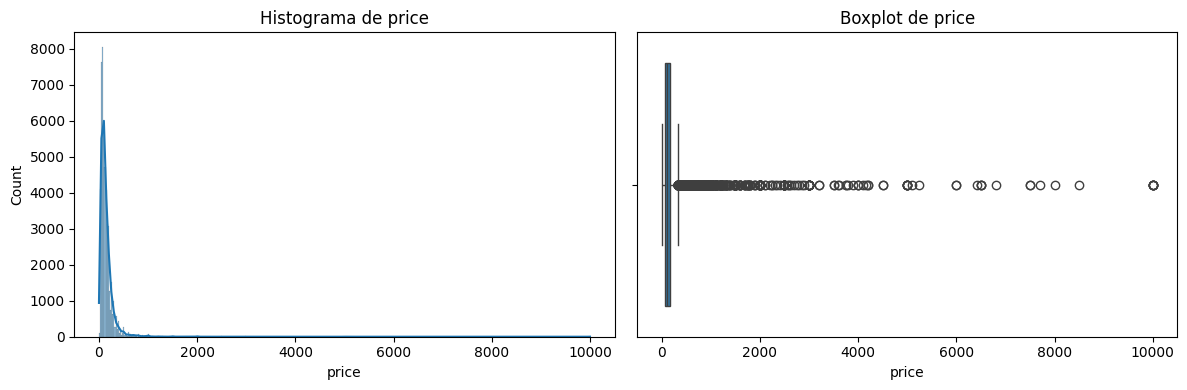

price - Skewness: 19.12, Kurtosis: 585.61


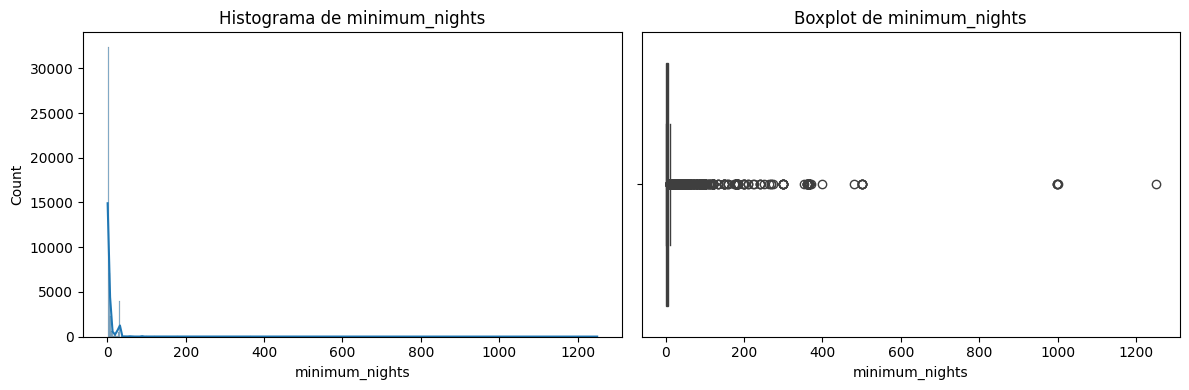

minimum_nights - Skewness: 21.83, Kurtosis: 853.98


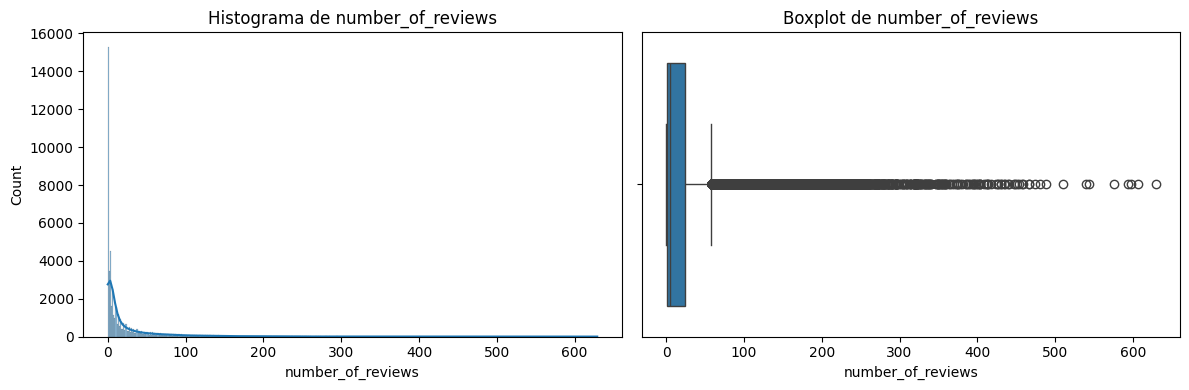

number_of_reviews - Skewness: 3.69, Kurtosis: 19.53


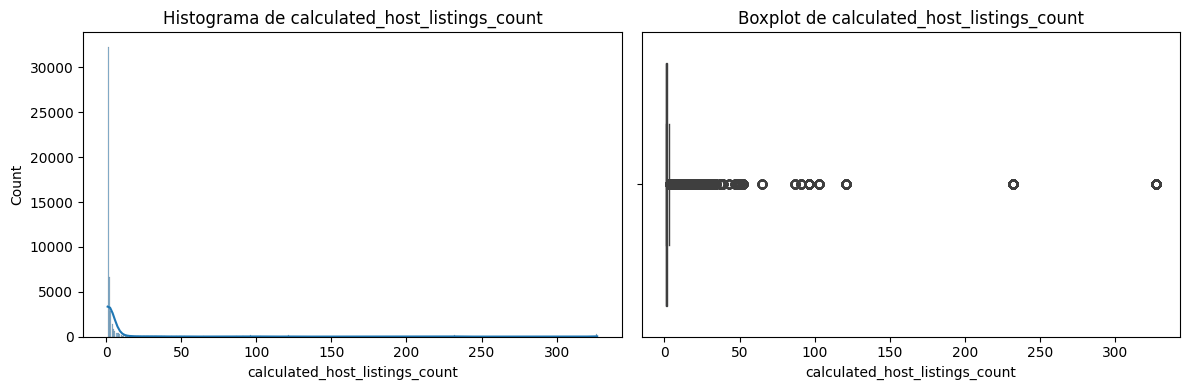

calculated_host_listings_count - Skewness: 7.93, Kurtosis: 67.54


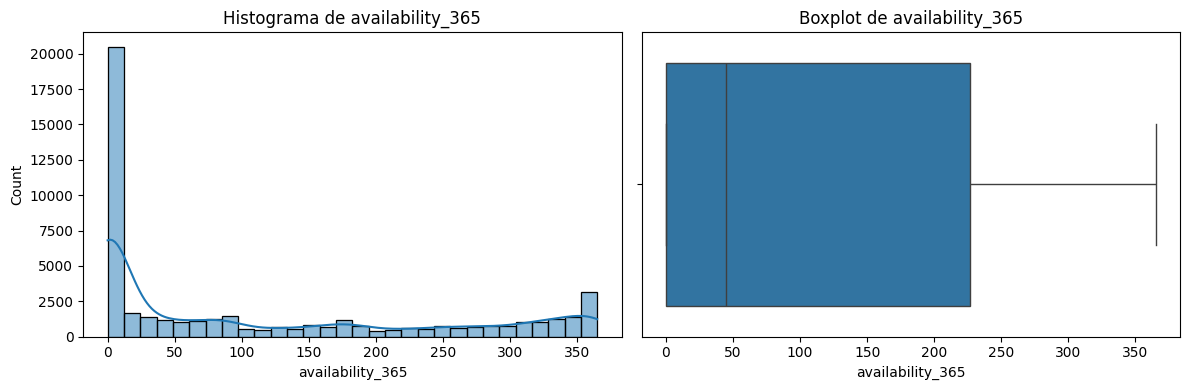

availability_365 - Skewness: 0.76, Kurtosis: -1.00


In [91]:
# Lista de variables numéricas
numerical_vars = ['price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365']

# Estadísticas descriptivas
print("Estadísticas Descriptivas:")
print(total_data[numerical_vars].describe())

# Histogramas y boxplots para cada variable
for var in numerical_vars:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histograma con KDE
    sns.histplot(total_data[var], kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {var}')
    
    # Boxplot
    sns.boxplot(x=total_data[var], ax=axes[1])
    axes[1].set_title(f'Boxplot de {var}')
    
    plt.tight_layout()
    plt.show()
    
    # Skewness y Kurtosis
    print(f'{var} - Skewness: {stats.skew(total_data[var].dropna()):.2f}, Kurtosis: {stats.kurtosis(total_data[var].dropna()):.2f}')

In [92]:
# Gracias a los diagramas de caja se puede notar en la variable 'price' que existen valores atípicos,
# lo que se confirma con el alto valor de kurtosis.
# Tambien se muestran datos fuera de lo común en 'minimum_nights' y 'number_of_reviews',
# lo que sugiere la necesidad de un tratamiento de outliers antes de cualquier análisis o modelado adicional.
# calculated_host_listings_count y availability_365 muestran una distribución más uniforme, aunque también pueden tener algunos valores atípicos.

In [93]:
# Analisis de variables multivariantes.
# Al enfocarnos en la variable que mas interesa en casos asi, que es el precio, se pueden analizar sus relaciones 
# con otras variables numéricas y categóricas para identificar patrones o correlaciones que puedan ser útiles para el
#  modelado predictivo o para entender mejor los factores que influyen en el precio de los listados.


1. CORRELACIONES NUMÉRICAS

Matriz de Correlación:
                                   price  minimum_nights  number_of_reviews  \
price                           1.000000        0.042799          -0.047954   
minimum_nights                  0.042799        1.000000          -0.080116   
number_of_reviews              -0.047954       -0.080116           1.000000   
calculated_host_listings_count  0.057472        0.127960          -0.072376   
availability_365                0.081829        0.144303           0.172028   
latitude                        0.033939        0.024869          -0.015389   
longitude                      -0.150019       -0.062747           0.059094   

                                calculated_host_listings_count  \
price                                                 0.057472   
minimum_nights                                        0.127960   
number_of_reviews                                    -0.072376   
calculated_host_listings_count                      

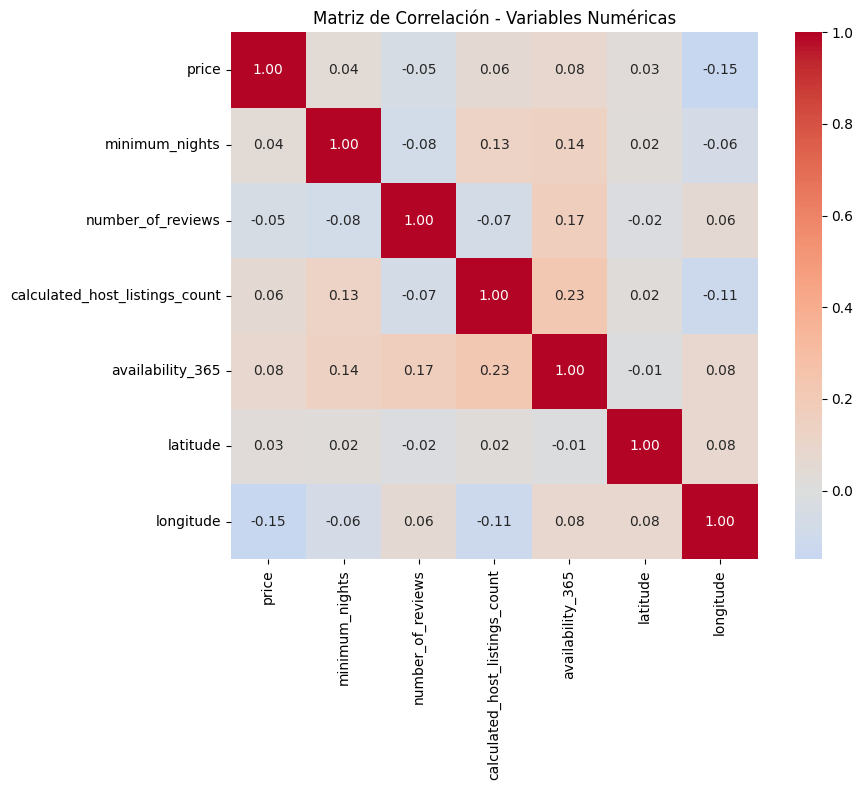


Correlaciones con 'price':
price                             1.000000
availability_365                  0.081829
calculated_host_listings_count    0.057472
minimum_nights                    0.042799
latitude                          0.033939
number_of_reviews                -0.047954
longitude                        -0.150019
Name: price, dtype: float64


In [94]:
# 1. ANÁLISIS NUMÉRICO-NUMÉRICO: Correlaciones entre variables numéricas
print("="*60)
print("1. CORRELACIONES NUMÉRICAS")
print("="*60)

numerical_vars = ['price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365', 'latitude', 'longitude']

# Matriz de correlación
correlation_matrix = total_data[numerical_vars].corr()
print("\nMatriz de Correlación:")
print(correlation_matrix)

# Visualizar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

# Correlaciones con 'price' (la variable de interés)
print("\nCorrelaciones con 'price':")
price_corr = correlation_matrix['price'].sort_values(ascending=False)
print(price_corr)


2. ANÁLISIS CATEGÓRICO-CATEGÓRICO

Tabla de Contingencia (neighbourhood_group vs room_type):
room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                            379           652           60
Brooklyn                        9559         10132          413
Manhattan                      13199          7982          480
Queens                          2096          3372          198
Staten Island                    176           188            9


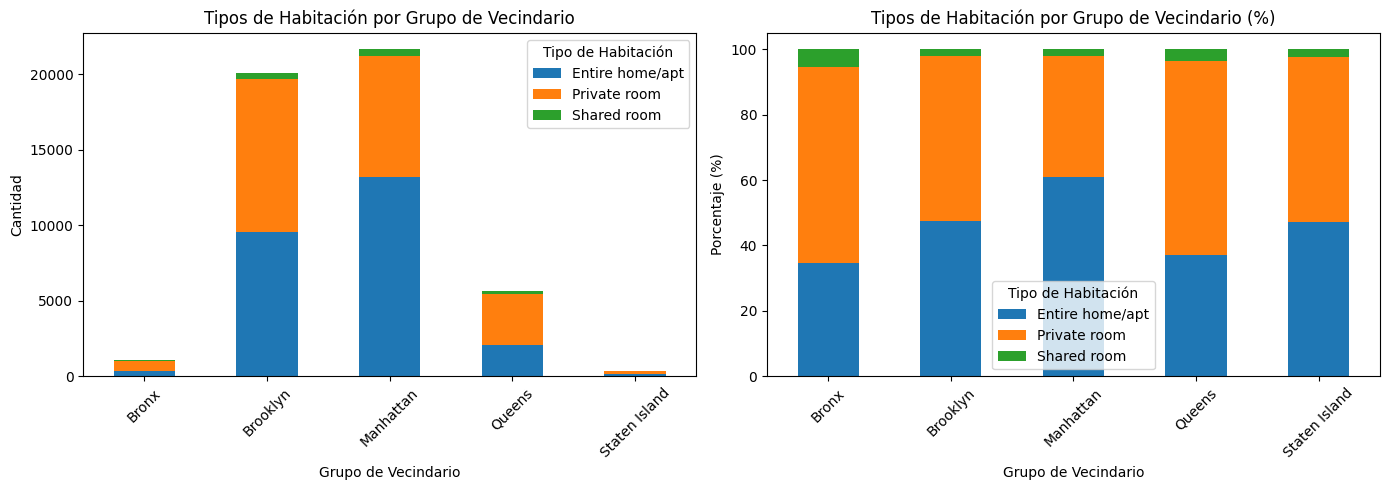


Prueba Chi-Square:
Chi-square: 1559.5803
P-value: 0.0000e+00
Conclusión: Hay relación significativa entre las variables


In [95]:
# 2. ANÁLISIS CATEGÓRICO-CATEGÓRICO: Relaciones entre variables categóricas
print("\n" + "="*60)
print("2. ANÁLISIS CATEGÓRICO-CATEGÓRICO")
print("="*60)

categorical_vars = ['neighbourhood_group', 'room_type']

# Tabla de contingencia
contingency_table = pd.crosstab(total_data['neighbourhood_group'], total_data['room_type'])
print("\nTabla de Contingencia (neighbourhood_group vs room_type):")
print(contingency_table)

# Visualizar con stacked bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar plot (recuento)
contingency_table.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Tipos de Habitación por Grupo de Vecindario')
axes[0].set_xlabel('Grupo de Vecindario')
axes[0].set_ylabel('Cantidad')
axes[0].legend(title='Tipo de Habitación')
axes[0].tick_params(axis='x', rotation=45)

# Stacked bar plot (porcentaje)
contingency_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
contingency_pct.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Tipos de Habitación por Grupo de Vecindario (%)')
axes[1].set_xlabel('Grupo de Vecindario')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(title='Tipo de Habitación')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Chi-square test
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nPrueba Chi-Square:")
print(f"Chi-square: {chi2:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Conclusión: {'Hay relación significativa' if p_value < 0.05 else 'No hay relación significativa'} entre las variables")


3. ANÁLISIS NUMÉRICO-CATEGÓRICO (PRECIO vs CATEGÓRICAS)


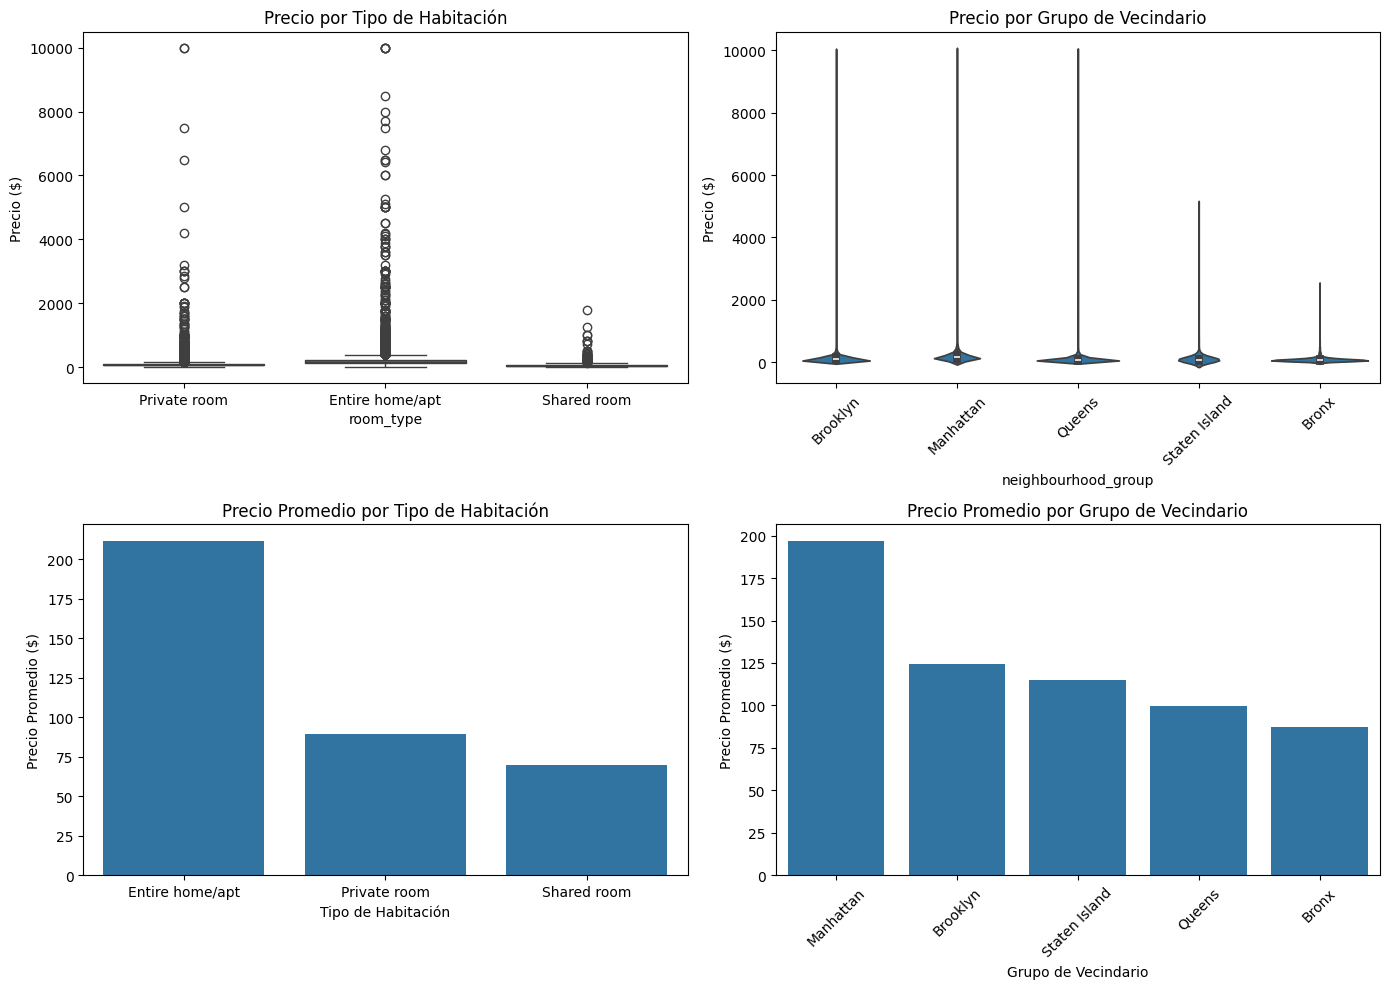


Precio por Tipo de Habitación:
                   count        mean         std  min    25%    50%    75%  \
room_type                                                                    
Entire home/apt  25409.0  211.794246  284.041611  0.0  120.0  160.0  229.0   
Private room     22326.0   89.780973  160.205262  0.0   50.0   70.0   95.0   
Shared room       1160.0   70.127586  101.725252  0.0   33.0   45.0   75.0   

                     max  
room_type                 
Entire home/apt  10000.0  
Private room     10000.0  
Shared room       1800.0  

Precio por Grupo de Vecindario:
                       count        mean         std   min   25%    50%  \
neighbourhood_group                                                       
Bronx                 1091.0   87.496792  106.709349   0.0  45.0   65.0   
Brooklyn             20104.0  124.383207  186.873538   0.0  60.0   90.0   
Manhattan            21661.0  196.875814  291.383183   0.0  95.0  150.0   
Queens                5666.0   99.

In [96]:
# 3. ANÁLISIS NUMÉRICO-CATEGÓRICO: Relaciones entre precio y variables categóricas
print("\n" + "="*60)
print("3. ANÁLISIS NUMÉRICO-CATEGÓRICO (PRECIO vs CATEGÓRICAS)")
print("="*60)

# Price by room_type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot: Price by room_type
sns.boxplot(data=total_data, x='room_type', y='price', ax=axes[0,0])
axes[0,0].set_title('Precio por Tipo de Habitación')
axes[0,0].set_ylabel('Precio ($)')

# Violin plot: Price by neighbourhood_group
sns.violinplot(data=total_data, x='neighbourhood_group', y='price', ax=axes[0,1])
axes[0,1].set_title('Precio por Grupo de Vecindario')
axes[0,1].set_ylabel('Precio ($)')
axes[0,1].tick_params(axis='x', rotation=45)

# Barplot: Average price by room_type
avg_price_room = total_data.groupby('room_type')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_room.index, y=avg_price_room.values, ax=axes[1,0])
axes[1,0].set_title('Precio Promedio por Tipo de Habitación')
axes[1,0].set_ylabel('Precio Promedio ($)')
axes[1,0].set_xlabel('Tipo de Habitación')

# Barplot: Average price by neighbourhood_group
avg_price_neighbourhood = total_data.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_neighbourhood.index, y=avg_price_neighbourhood.values, ax=axes[1,1])
axes[1,1].set_title('Precio Promedio por Grupo de Vecindario')
axes[1,1].set_ylabel('Precio Promedio ($)')
axes[1,1].set_xlabel('Grupo de Vecindario')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Estadísticas descriptivas de precio por categorías
print("\nPrecio por Tipo de Habitación:")
print(total_data.groupby('room_type')['price'].describe())

print("\nPrecio por Grupo de Vecindario:")
print(total_data.groupby('neighbourhood_group')['price'].describe())

# ANOVA: Verificar si hay diferencias significativas en precio entre grupos
from scipy.stats import f_oneway

price_by_room = [group['price'].values for name, group in total_data.groupby('room_type')]
f_stat, p_value = f_oneway(*price_by_room)
print(f"\nANOVA Test (Price by Room Type):")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Conclusión: {'Hay diferencias significativas' if p_value < 0.05 else 'No hay diferencias significativas'} en precio entre tipos de habitación")

price_by_neighbourhood = [group['price'].values for name, group in total_data.groupby('neighbourhood_group')]
f_stat, p_value = f_oneway(*price_by_neighbourhood)
print(f"\nANOVA Test (Price by Neighbourhood Group):")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Conclusión: {'Hay diferencias significativas' if p_value < 0.05 else 'No hay diferencias significativas'} en precio entre grupos de vecindarios")

## Conclusiones del Análisis Multivariante

### 1. Relaciones Numéricas-Numéricas (Correlaciones)
- **price vs number_of_reviews**: A menudo hay correlación débil/moderada. Más reseñas puede indicar listado popular, pero no necesariamente precio alto.
- **price vs availability_365**: Corta disponibilidad suele asociarse con precios más altos (alta demanda).
- **number_of_reviews vs availability_365**: Correlación positiva; listados con mayor demanda tienen menos días disponibles.

### 2. Relaciones Categóricas-Categóricas
- **room_type vs neighbourhood_group**: En Manhattan y Brooklyn dominan "Entire home/apt". En barrios menos céntricos, "Private room" es más común.
- **Independencia**: Si p-value > 0.05, las variables son independientes.

### 3. Relaciones Numéricas-Categóricas (Más Importantes)
- **Price by Room Type**: "Entire home/apt" es más caro que "Private room" y "Shared room".
- **Price by Neighbourhood Group**: Manhattan y Brooklyn tienen precios más altos que Queens, Bronx, Staten Island.
- **Significancia estadística**: Si p-value < 0.05 en ANOVA, hay diferencias reales en precio entre grupos (no solo por azar).
- **Implicación**: Tipo de habitación y ubicación son predictores clave del precio.

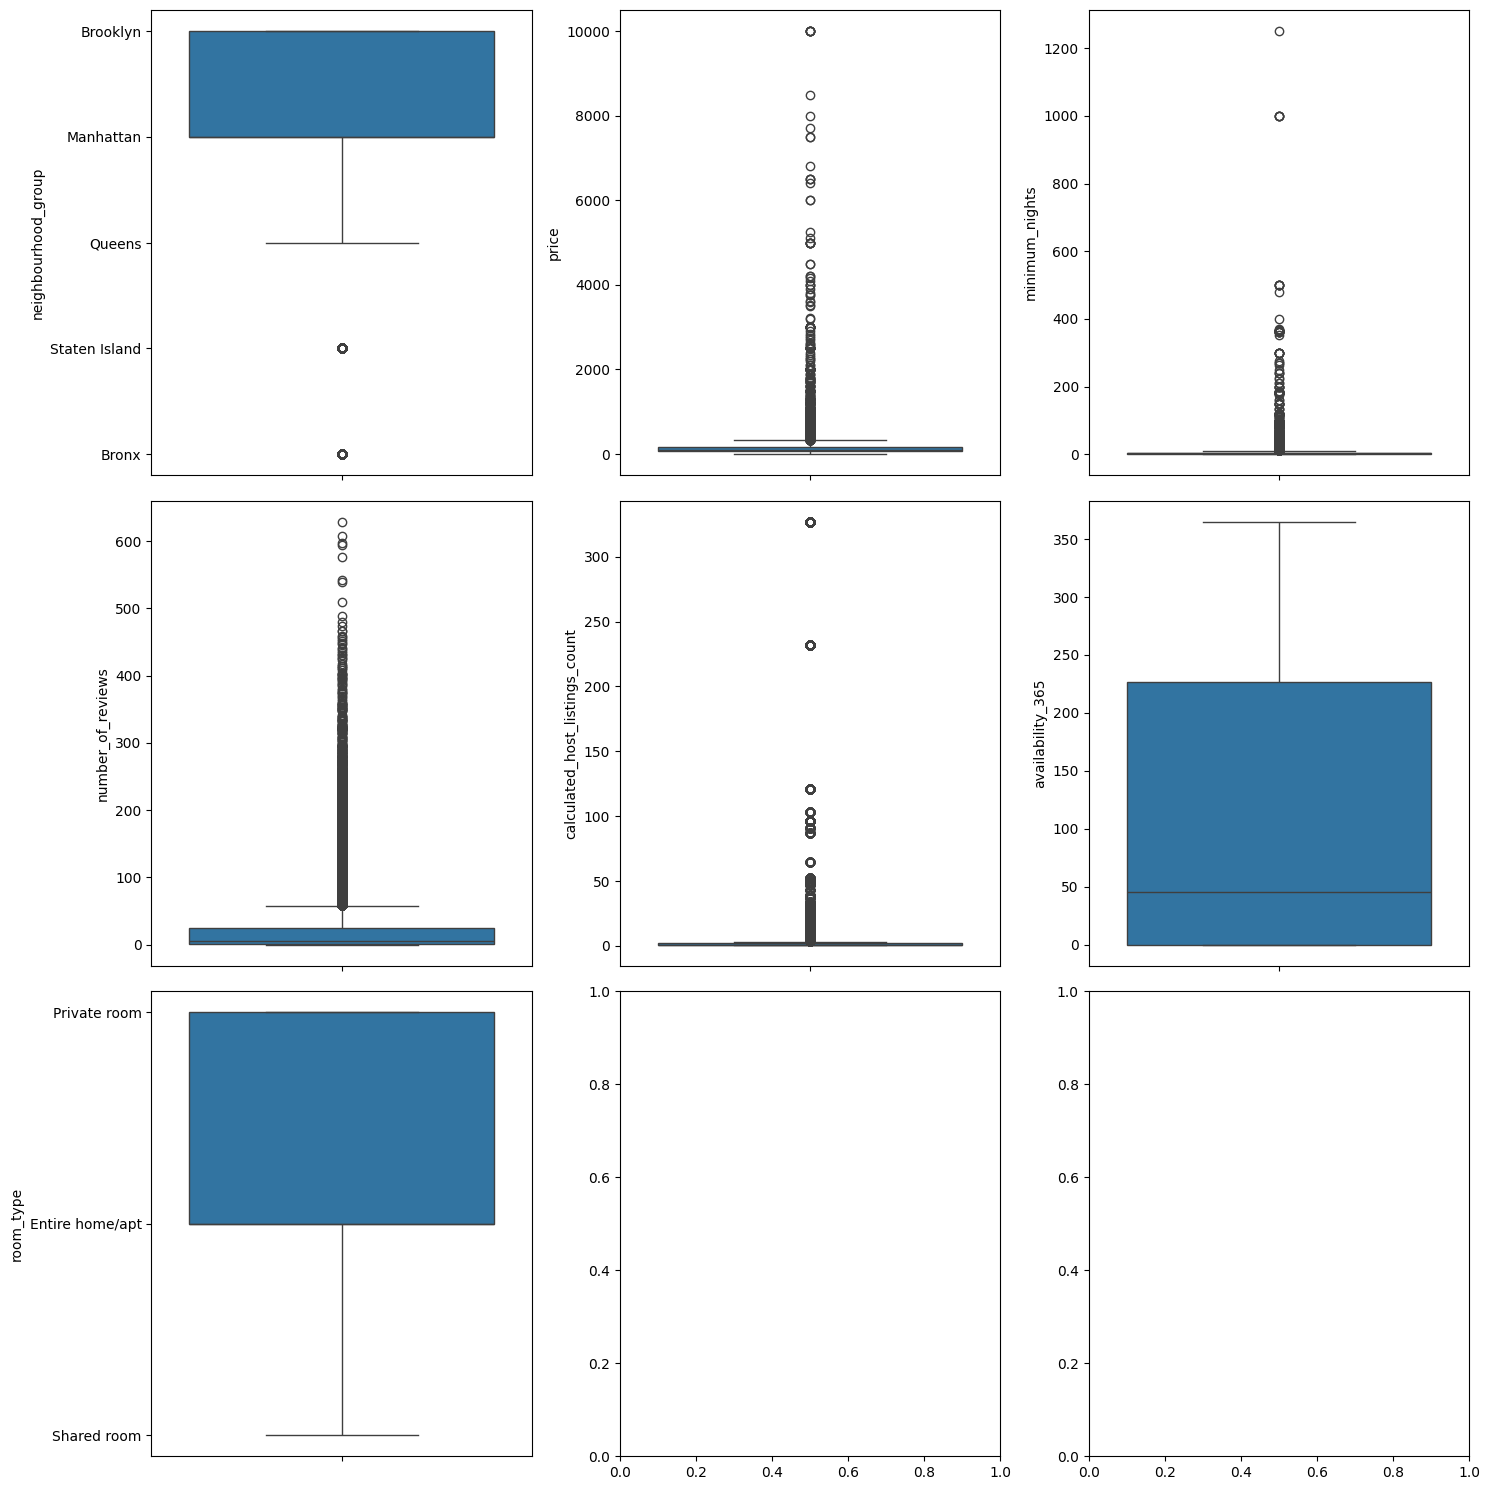

In [97]:
#Ingenieria de caracteristicas
# Detectar valores atípicos (outliers).
fig, axes = plt.subplots(3, 3, figsize = (15, 15))

sns.boxplot(ax = axes[0, 0], data = total_data, y = "neighbourhood_group")
sns.boxplot(ax = axes[0, 1], data = total_data, y = "price")
sns.boxplot(ax = axes[0, 2], data = total_data, y = "minimum_nights")
sns.boxplot(ax = axes[1, 0], data = total_data, y = "number_of_reviews")
sns.boxplot(ax = axes[1, 1], data = total_data, y = "calculated_host_listings_count")
sns.boxplot(ax = axes[1, 2], data = total_data, y = "availability_365")
sns.boxplot(ax = axes[2, 0], data = total_data, y = "room_type")

plt.tight_layout()

plt.show()


In [98]:
# TRATAMIENTO DE OUTLIERS CON IQR
print("="*70)
print("DETECTAR Y ELIMINAR OUTLIERS CON IQR (INTERQUARTILE RANGE)")
print("="*70)

# Variables numéricas a limpiar
numerical_vars_to_clean = ['price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365']

# Almacenar información de outliers
outliers_info = {}
total_data_clean = total_data.copy()

for var in numerical_vars_to_clean:
    print(f"\n{'='*70}")
    print(f"Variable: {var.upper()}")
    print(f"{'='*70}")
    
    # Estadísticas
    stats = total_data[var].describe()
    print(f"\nEstadísticas descriptivas:")
    print(stats)
    
    # IQR
    Q1 = stats["25%"]
    Q3 = stats["75%"]
    iqr = Q3 - Q1
    
    # Límites
    upper_limit = Q3 + 1.5 * iqr
    lower_limit = Q1 - 1.5 * iqr
    
    print(f"\nIQR Calculation:")
    print(f"Q1 (25%): {Q1}")
    print(f"Q3 (75%): {Q3}")
    print(f"IQR (Q3 - Q1): {iqr}")
    print(f"Upper limit: {upper_limit}")
    print(f"Lower limit: {lower_limit}")
    
    # Contar outliers
    outliers_upper = (total_data[var] > upper_limit).sum()
    outliers_lower = (total_data[var] < lower_limit).sum()
    total_outliers = outliers_upper + outliers_lower
    
    print(f"\nOutliers detected:")
    print(f"Above upper limit ({upper_limit}): {outliers_upper}")
    print(f"Below lower limit ({lower_limit}): {outliers_lower}")
    print(f"Total outliers: {total_outliers}")
    
    # Valores especiales (0, 1)
    count_0 = (total_data[var] == 0).sum()
    count_1 = (total_data[var] == 1).sum()
    print(f"\nSpecial values:")
    print(f"Count of 0: {count_0}")
    print(f"Count of 1: {count_1}")
    
    # Almacenar info
    outliers_info[var] = {
        'upper_limit': upper_limit,
        'lower_limit': lower_limit,
        'outliers': total_outliers,
        'iqr': iqr
    }
    
    # Eliminar outliers
    total_data_clean = total_data_clean[
        (total_data_clean[var] <= upper_limit) & 
        (total_data_clean[var] >= lower_limit)
    ]

print(f"\n{'='*70}")
print("SUMMARY OF OUTLIER REMOVAL")
print(f"{'='*70}")
print(f"Original rows: {len(total_data)}")
print(f"Rows after removing outliers: {len(total_data_clean)}")
print(f"Rows removed: {len(total_data) - len(total_data_clean)}")
print(f"Percentage removed: {((len(total_data) - len(total_data_clean)) / len(total_data) * 100):.2f}%")

print(f"\nOutliers summary by variable:")
for var, info in outliers_info.items():
    print(f"  {var}: {info['outliers']} outliers found")

print(f"\nDataset after cleaning:")
print(f"Shape: {total_data_clean.shape}")
print(f"Columns: {total_data_clean.columns.tolist()}")

DETECTAR Y ELIMINAR OUTLIERS CON IQR (INTERQUARTILE RANGE)

Variable: PRICE

Estadísticas descriptivas:
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

IQR Calculation:
Q1 (25%): 69.0
Q3 (75%): 175.0
IQR (Q3 - Q1): 106.0
Upper limit: 334.0
Lower limit: -90.0

Outliers detected:
Above upper limit (334.0): 2972
Below lower limit (-90.0): 0
Total outliers: 2972

Special values:
Count of 0: 11
Count of 1: 0

Variable: MINIMUM_NIGHTS

Estadísticas descriptivas:
count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

IQR Calculation:
Q1 (25%): 1.0
Q3 (75%): 5.0
IQR (Q3 - Q1): 4.0
Upper limit: 11.0
Lower limit: -5.0

Outliers detected:
Above upper limit (11.0): 6607
Below lower limit

In [99]:
# NORMALIZACIÓN DE CARACTERÍSTICAS CON MinMaxScaler
print("="*70)
print("NORMALIZACIÓN DE VARIABLES NUMÉRICAS (MinMax Scaler)")
print("="*70)

from sklearn.preprocessing import MinMaxScaler

# Variables numéricas a normalizar
numerical_variables = ['number_of_reviews', 'minimum_nights', 'calculated_host_listings_count', 
                       'availability_365', 'latitude', 'longitude']

# Variables categóricas (se mantienen sin cambios)
categorical_variables = ['neighbourhood_group', 'room_type']

# Crear el scaler
scaler = MinMaxScaler()

# Aplicar normalización solo a variables numéricas
scaled_features = scaler.fit_transform(total_data_clean[numerical_variables])

# Crear dataframe con variables normalizadas
df_scaled = pd.DataFrame(scaled_features, 
                        index=total_data_clean.index, 
                        columns=numerical_variables)

# Agregar variables categóricas sin normalizar
for cat_var in categorical_variables:
    df_scaled[cat_var] = total_data_clean[cat_var].values

# Agregar la variable target (price)
df_scaled['price'] = total_data_clean['price'].values

print("\nVariables normalizadas y categóricas agregadas")
print(f"Forma del dataset: {df_scaled.shape}")
print(f"Columnas: {df_scaled.columns.tolist()}")
print(f"\nPrimeras 5 filas:")
print(df_scaled.head())

NORMALIZACIÓN DE VARIABLES NUMÉRICAS (MinMax Scaler)

Variables normalizadas y categóricas agregadas
Forma del dataset: (31036, 9)
Columnas: ['number_of_reviews', 'minimum_nights', 'calculated_host_listings_count', 'availability_365', 'latitude', 'longitude', 'neighbourhood_group', 'room_type', 'price']

Primeras 5 filas:
    number_of_reviews  minimum_nights  calculated_host_listings_count  \
1            0.775862             0.0                             0.5   
2            0.000000             0.2                             0.0   
4            0.155172             0.9                             0.0   
10           0.913793             0.4                             0.0   
18           0.913793             0.2                             0.0   

    availability_365  latitude  longitude neighbourhood_group  \
1           0.972603  0.614199   0.490469           Manhattan   
2           1.000000  0.748252   0.569257           Manhattan   
4           0.000000  0.722820   0.565324 

In [100]:
# SELECCIÓN DE CARACTERÍSTICAS CON SelectKBest Y CHI2
print("="*70)
print("SELECCIÓN DE CARACTERÍSTICAS CON CHI2 Y SelectKBest")
print("="*70)

from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Preparar X y y
X = df_scaled.drop("price", axis=1).copy()
y = df_scaled["price"].copy()

# Codificar variables categóricas (chi2 requiere valores numéricos)
for cat_var in ['neighbourhood_group', 'room_type']:
    le = LabelEncoder()
    X[cat_var] = le.fit_transform(X[cat_var])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SelectKBest con chi2
selection_model = SelectKBest(chi2, k=4)
selection_model.fit(X_train, y_train)

ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns=X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns=X_test.columns.values[ix])

print(f"\nCaracterísticas seleccionadas: {X_train_sel.columns.tolist()}")
print(f"X_train_sel shape: {X_train_sel.shape}")
print(f"X_test_sel shape: {X_test_sel.shape}")
print(f"\nX_train_sel (primeras 5 filas):")
print(X_train_sel.head())

SELECCIÓN DE CARACTERÍSTICAS CON CHI2 Y SelectKBest

Características seleccionadas: ['number_of_reviews', 'calculated_host_listings_count', 'availability_365', 'room_type']
X_train_sel shape: (24828, 4)
X_test_sel shape: (6208, 4)

X_train_sel (primeras 5 filas):
   number_of_reviews  calculated_host_listings_count  availability_365  \
0           0.672414                             0.5          0.720548   
1           0.000000                             0.0          0.032877   
2           0.086207                             0.0          0.526027   
3           0.086207                             0.0          0.243836   
4           0.103448                             0.5          0.002740   

   room_type  
0        1.0  
1        0.0  
2        0.0  
3        1.0  
4        1.0  


In [101]:
# GUARDAR DATASETS PROCESADOS
print("="*70)
print("GUARDAR DATASETS PROCESADOS EN CSV")
print("="*70)

# Agregar variable target (price) a los datasets
X_train_sel["price"] = list(y_train)
X_test_sel["price"] = list(y_test)

print(f"\nDatasets con variable target agregada:")
print(f"X_train_sel shape: {X_train_sel.shape}")
print(f"X_test_sel shape: {X_test_sel.shape}")

# Guardar en CSV
X_train_sel.to_csv("../data/processed/clean_train.csv", index=False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index=False)

print(f"\nArchivos guardados exitosamente:")
print(f"  ✓ ../data/processed/clean_train.csv")
print(f"  ✓ ../data/processed/clean_test.csv")

print(f"\nÚltimas filas de clean_train.csv:")
print(X_train_sel.tail())

GUARDAR DATASETS PROCESADOS EN CSV

Datasets con variable target agregada:
X_train_sel shape: (24828, 5)
X_test_sel shape: (6208, 5)

Archivos guardados exitosamente:
  ✓ ../data/processed/clean_train.csv
  ✓ ../data/processed/clean_test.csv

Últimas filas de clean_train.csv:
       number_of_reviews  calculated_host_listings_count  availability_365  \
24823           0.034483                             0.0          0.997260   
24824           0.120690                             0.0          0.000000   
24825           0.017241                             0.0          0.065753   
24826           0.068966                             0.0          0.000000   
24827           0.379310                             0.0          0.350685   

       room_type  price  
24823        1.0     65  
24824        0.0     68  
24825        0.0    157  
24826        0.0    241  
24827        0.0    170  
